In [259]:
library(tidyverse)
library(dplyr) 
library(ggplot2)
library(cowplot)
library(BSDA)

# Load files ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

In [260]:
# Read file
fp_tp2 <- read.csv("/ceph/projects/010_SweMaMi/bm.nowak/filtered_data/feacal/tp2_nulliparous/2025-08-18_fp_tp2_filt.csv", header = TRUE)
sp_tp2 <- read.csv("/ceph/projects/010_SweMaMi/bm.nowak/filtered_data/feacal/tp2_nulliparous/2025-08-18_sp_tp2_filt.csv", header = TRUE)
combined_fp_sp_tp2 <- read.csv("/ceph/projects/010_SweMaMi/bm.nowak/filtered_data/feacal/tp2_nulliparous/2025-08-18_combined_fp_sp_tp2.csv", header = TRUE)

In [261]:
head(fp_tp2)
dim(fp_tp2)

,X,Studienummer,Correct_PN,Prev_RPL,Prev_IUFD,Prev_miscarriage_numb,Q1_Datum,Q1_Personnummer,Avbruten_graviditet,age_checked,⋯,diffdays,missfall.IUFD_week,IUFD,missfall,missfall.IUFD_comments,Gest_w_combined,deliv_start_combined,Type_of_PTB,s_PTB,preeclampsia_epi_analysis
,<int>,<chr>,<lgl>,<int>,<int>,<int>,<chr>,<chr>,<int>,<int>,⋯,<int>,<lgl>,<lgl>,<lgl>,<lgl>,<int>,<chr>,<chr>,<int>,<int>
1,5367,S194e21b,NA,0,0,0,2018-11-16,P159f9c8,0,36,⋯,0,NA,NA,NA,NA,41,Spontaneous,NA,NA,0
2,5297,S1a267fa,NA,0,0,0,2019-05-23,P1a267fa,0,32,⋯,0,NA,NA,NA,NA,38,Spontaneous,NA,NA,0
3,5301,S1f862a6,NA,0,0,0,2018-03-07,P1f862a6,0,32,⋯,0,NA,NA,NA,NA,31,Spontaneous,very_w28_31,1,0
4,5285,S3c0f6ee,NA,0,0,0,2019-03-25,P3c0f6ee,0,31,⋯,0,NA,NA,NA,NA,38,Spontaneous,NA,NA,0
5,5275,S2b86cc0,NA,0,0,0,2019-05-29,P3cac7b0,0,31,⋯,0,NA,NA,NA,NA,39,Spontaneous,NA,NA,0
6,5243,S39fe1d7,NA,0,0,0,2018-06-23,P3db7da6,0,29,⋯,0,NA,NA,NA,NA,41,Spontaneous,NA,NA,0


[1]  24 566

In [262]:
head(sp_tp2)
dim(sp_tp2)

,X,Studienummer,Correct_PN,Prev_RPL,Prev_IUFD,Prev_miscarriage_numb,Q1_Datum,Q1_Personnummer,Avbruten_graviditet,age_checked,⋯,diffdays,missfall.IUFD_week,IUFD,missfall,missfall.IUFD_comments,Gest_w_combined,deliv_start_combined,Type_of_PTB,s_PTB,preeclampsia_epi_analysis
,<int>,<chr>,<lgl>,<int>,<int>,<int>,<chr>,<chr>,<int>,<int>,⋯,<int>,<lgl>,<lgl>,<lgl>,<lgl>,<int>,<chr>,<lgl>,<lgl>,<int>
1,5391,S159f9c8,NA,0,0,0,2021-01-28,P159f9c8,0,38,⋯,0,NA,NA,NA,NA,40,Spontaneous,NA,NA,0
2,5332,Sb124b17,NA,0,0,2,2021-01-06,P1a267fa,0,34,⋯,0,NA,NA,NA,NA,41,Spontaneous,NA,NA,0
3,5305,Sa79a719,NA,0,0,1,2019-01-17,P1f862a6,0,32,⋯,0,NA,NA,NA,NA,41,Induction,NA,NA,0
4,5310,S5097402,NA,0,0,1,2020-10-18,P3c0f6ee,0,33,⋯,0,NA,NA,NA,NA,39,Spontaneous,NA,NA,0
5,5311,S3cac7b0,NA,0,0,0,2020-10-20,P3cac7b0,0,33,⋯,0,NA,NA,NA,NA,40,Spontaneous,NA,NA,0
6,5252,S3db7da6,NA,0,0,1,2019-09-24,P3db7da6,0,30,⋯,0,NA,NA,NA,NA,39,Spontaneous,NA,NA,0


[1]  24 566

In [263]:
head(combined_fp_sp_tp2)
dim(combined_fp_sp_tp2)

,X,Studienummer,Correct_PN,Prev_RPL,Prev_IUFD,Prev_miscarriage_numb,Q1_Datum,Q1_Personnummer,Avbruten_graviditet,age_checked,⋯,missfall.IUFD_week,IUFD,missfall,missfall.IUFD_comments,Gest_w_combined,deliv_start_combined,Type_of_PTB,s_PTB,preeclampsia_epi_analysis,Group
,<int>,<chr>,<lgl>,<int>,<int>,<int>,<chr>,<chr>,<int>,<int>,⋯,<lgl>,<lgl>,<lgl>,<lgl>,<int>,<chr>,<chr>,<int>,<int>,<chr>
1,5367,S194e21b,NA,0,0,0,2018-11-16,P159f9c8,0,36,⋯,NA,NA,NA,NA,41,Spontaneous,NA,NA,0,First pregnancy
2,5297,S1a267fa,NA,0,0,0,2019-05-23,P1a267fa,0,32,⋯,NA,NA,NA,NA,38,Spontaneous,NA,NA,0,First pregnancy
3,5301,S1f862a6,NA,0,0,0,2018-03-07,P1f862a6,0,32,⋯,NA,NA,NA,NA,31,Spontaneous,very_w28_31,1,0,First pregnancy
4,5285,S3c0f6ee,NA,0,0,0,2019-03-25,P3c0f6ee,0,31,⋯,NA,NA,NA,NA,38,Spontaneous,NA,NA,0,First pregnancy
5,5275,S2b86cc0,NA,0,0,0,2019-05-29,P3cac7b0,0,31,⋯,NA,NA,NA,NA,39,Spontaneous,NA,NA,0,First pregnancy
6,5243,S39fe1d7,NA,0,0,0,2018-06-23,P3db7da6,0,29,⋯,NA,NA,NA,NA,41,Spontaneous,NA,NA,0,First pregnancy


[1]  48 567

# Quantitative, ordinal data ============================================================================

## Age

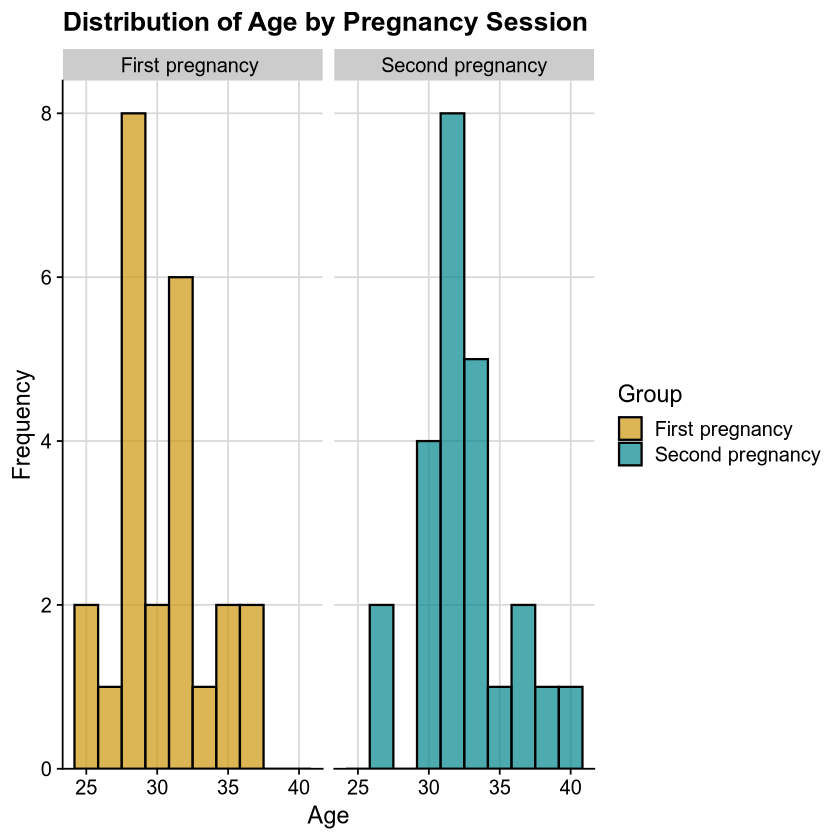

In [264]:
dye <- c("First pregnancy " = "darkgoldenrod3", "Second pregnancy" = "turquoise4")

# Histogram of age distribution, grouped by pregnancy session (First vs Second)
age_histogram_combined <- combined_fp_sp_tp2 |>
  ggplot(aes(x = age_checked, fill = Group)) +
  geom_histogram(bins = 10, col="black", alpha = 0.7, na.rm = TRUE)+
  facet_wrap(~ Group) + # Create one histogram per group 
  labs(
    x = "Age",
    y ="Frequency",
    title ="Distribution of Age by Pregnancy Session"
  ) +
  scale_y_continuous(
    # Don't expand y scale at the lower end
    expand = expansion(mult = c(0, 0.05))
  ) +    
    scale_fill_manual(values = dye) 
age_histogram_combined + theme_half_open() +
  background_grid()

In [265]:
# Shapiro test
# In agreement with histogram --> normaly distributed
shapiro_p <- shapiro.test(combined_fp_sp_tp2$age_checked)
shapiro_p


	Shapiro-Wilk normality test

data:  combined_fp_sp_tp2$age_checked
W = 0.97421, p-value = 0.3659


In [266]:
combined_fp_sp_sorted <- combined_fp_sp_tp2[ order(combined_fp_sp_tp2$Q1_Personnummer, combined_fp_sp_tp2$Group), ]

fp_data <- combined_fp_sp_sorted$age_checked[combined_fp_sp_sorted$Group == "First pregnancy "]
sp_data <- combined_fp_sp_sorted$age_checked[combined_fp_sp_sorted$Group == "Second pregnancy"]
t.test(fp_data, sp_data, paired = TRUE)


	Paired t-test

data:  fp_data and sp_data
t = -16.613, df = 23, p-value = 2.642e-14
alternative hypothesis: true mean difference is not equal to 0
95 percent confidence interval:
 -2.249037 -1.750963
sample estimates:
mean difference 
             -2 


## BMI (numerical) ----------------------------------------------------------------------

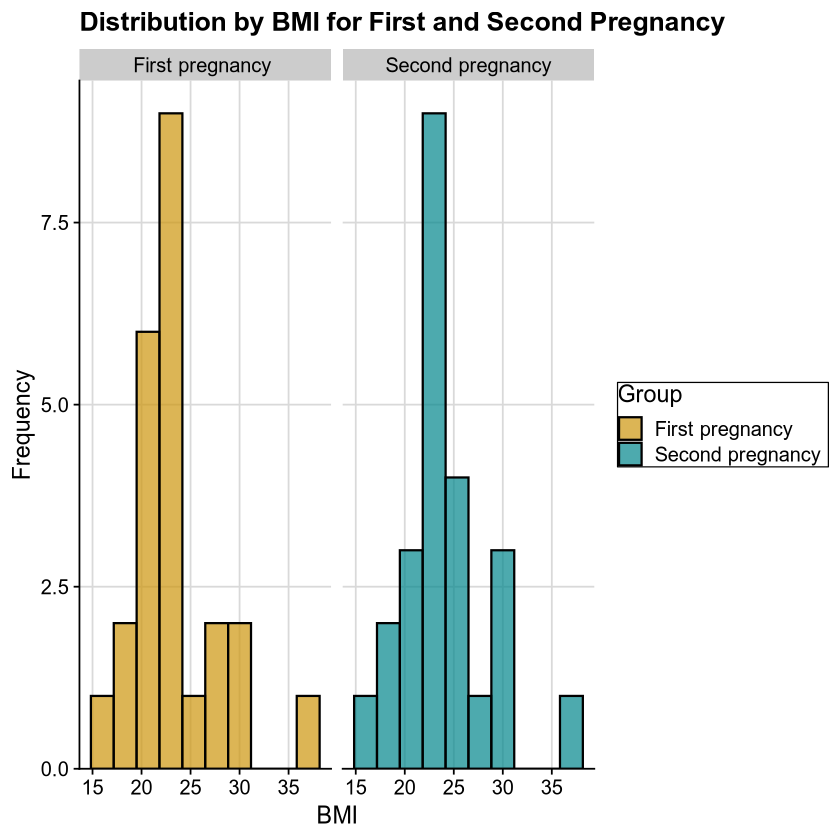

In [267]:
bmi_histogram_combined <- combined_fp_sp_tp2 |>
  ggplot(aes(x = BMI_prior, fill =Group)) +
  geom_histogram(bins = 10, col = "black", alpha = 0.7, na.rm = TRUE) +
  facet_wrap(~ Group) +
  labs(
    x = "BMI",
    y = "Frequency",
    title = "Distribution by BMI for First and Second Pregnancy"
  ) +
  scale_y_continuous(
    # Don't expand y scale at the lower end
    expand = expansion(mult = c(0, 0.05))
  ) +
    scale_fill_manual(values = dye) +
  theme_half_open() +
  background_grid() +
  theme(
    legend.box.background = element_rect(color = "black")
  )
bmi_histogram_combined

In [268]:
# Shapiro test
shapiro_bmi <- shapiro.test(combined_fp_sp_tp2$BMI_prior)
shapiro_bmi


	Shapiro-Wilk normality test

data:  combined_fp_sp_tp2$BMI_prior
W = 0.91728, p-value = 0.002386


In [269]:
wilcox_bmi <- wilcox.test(
  combined_fp_sp_tp2$BMI_prior[combined_fp_sp_tp2$Group == "First pregnancy "],
  combined_fp_sp_tp2$BMI_prior[combined_fp_sp_tp2$Group == "Second pregnancy"],
  paired = TRUE
)
wilcox_bmi

Warning message in wilcox.test.default(combined_fp_sp_tp2$BMI_prior[combined_fp_sp_tp2$Group == :
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(combined_fp_sp_tp2$BMI_prior[combined_fp_sp_tp2$Group == :
“cannot compute exact p-value with zeroes”



	Wilcoxon signed rank test with continuity correction

data:  combined_fp_sp_tp2$BMI_prior[combined_fp_sp_tp2$Group == "First pregnancy "] and combined_fp_sp_tp2$BMI_prior[combined_fp_sp_tp2$Group == "Second pregnancy"]
V = 31.5, p-value = 0.02942
alternative hypothesis: true location shift is not equal to 0


# Categorical, Nominal data===============================================================================

## Excess weight  -----------------------------------------------------------------------

In [270]:
# Convert to factor
fp_tp2 <- fp_tp2 |>
  mutate(excess_weight = as.factor(ifelse(fp_tp2$excess_weight == "NA", NA, ifelse(excess_weight =="No", 0, 1)))) 
sp_tp2 <- sp_tp2 |>
  mutate(excess_weight = as.factor(ifelse(sp_tp2$excess_weight == "NA", NA, ifelse(excess_weight =="No", 0, 1)))) 

In [271]:
# Select variables of interest
fp_excess_weight <- fp_tp2 |>
  select(Q1_Personnummer, excess_weight)
sp_excess_weight <- sp_tp2 |>
  select(Q1_Personnummer, excess_weight)

In [272]:
combined_df_excess_weight <-  merge(fp_excess_weight, sp_excess_weight, by = "Q1_Personnummer", suffixes = c("_FP", "_SP"))
dim(combined_df_excess_weight)

[1] 24  3

In [273]:
combined_df_excess_weight |> filter(is.na(combined_df_excess_weight$excess_weight_FP) & is.na(combined_df_excess_weight$excess_weight_SP))

Q1_Personnummer,excess_weight_FP,excess_weight_SP
<chr>,<fct>,<fct>


In [274]:
# The missing values for same participant so use Mc Nemar

In [275]:
# Contingency table
tab_excess_weight <- table(
    factor(combined_df_excess_weight$excess_weight_FP, levels = c(0, 1)),
    factor(combined_df_excess_weight$excess_weight_SP, levels= c (0, 1)))
tab_excess_weight

   
    0 1
  0 8 7
  1 1 6

In [276]:
# Non-parametric paired categorical data --> use McNemar's test
mcnemar.test(tab_excess_weight)


	McNemar's Chi-squared test with continuity correction

data:  tab_excess_weight
McNemar's chi-squared = 3.125, df = 1, p-value = 0.0771


## Diabetes----------------------------------------------------------------------

In [277]:
class(combined_fp_sp_tp2$Q2_X13.1.Pregproblem_gestational_diabetes)

[1] "character"

In [278]:
# Convert from char to fct
diabetes_category_fp <- ifelse(fp_tp2$Q2_X13.1.Pregproblem_gestational_diabetes == "Nej", 0, 
                            ifelse(fp_tp2$Q2_X13.1.Pregproblem_gestational_diabetes == "Ja", 1, NA))
diabetes_category_fp

diabetes_category_sp <- ifelse(sp_tp2$Q2_X13.1.Pregproblem_gestational_diabetes == "Nej", 0, 
                            ifelse(sp_tp2$Q2_X13.1.Pregproblem_gestational_diabetes == "Ja", 1, NA))
diabetes_category_sp

[1]  0 NA NA  1  0 NA NA NA NA NA NA NA NA NA NA NA NA NA NA NA  0  0 NA NA

[1] NA NA NA  1 NA NA NA NA NA NA  0 NA  0 NA NA NA NA NA NA NA NA NA NA NA

In [279]:
# Add diabetes category column as factors
fp_tp2$Q2_Diabetes_category <- as.factor(diabetes_category_fp)
class(fp_tp2$Q2_Diabetes_category)

sp_tp2$Q2_Diabetes_category <- as.factor(diabetes_category_sp)
class(sp_tp2$Q2_Diabetes_category)

[1] "factor"

[1] "factor"

In [280]:
# Select variables of interest
fp_diabetes <- fp_tp2 |>
  select(Q1_Personnummer, Q2_Diabetes_category)
fp_diabetes

sp_diabetes <- sp_tp2 |>
  select(Q1_Personnummer, Q2_Diabetes_category)
sp_diabetes

Q1_Personnummer,Q2_Diabetes_category
<chr>,<fct>
P159f9c8,0
P1a267fa,NA
P1f862a6,NA
P3c0f6ee,1
P3cac7b0,0
P3db7da6,NA
P424fd61,NA
P4a05456,NA
P4de45e7,NA


Q1_Personnummer,Q2_Diabetes_category
<chr>,<fct>
P159f9c8,NA
P1a267fa,NA
P1f862a6,NA
P3c0f6ee,1
P3cac7b0,NA
P3db7da6,NA
P424fd61,NA
P4a05456,NA
P4de45e7,NA


In [281]:
combined_df_diabetes <-  merge(fp_diabetes, sp_diabetes, by = "Q1_Personnummer", suffixes = c("_FP", "_SP"))
dim(combined_df_diabetes)
head(combined_df_diabetes)

[1] 24  3

,Q1_Personnummer,Q2_Diabetes_category_FP,Q2_Diabetes_category_SP
,<chr>,<fct>,<fct>
1,P159f9c8,0,NA
2,P1a267fa,NA,NA
3,P1f862a6,NA,NA
4,P3c0f6ee,1,1
5,P3cac7b0,0,NA
6,P3db7da6,NA,NA


In [282]:
tab_diabetes <- table(combined_df_diabetes$Q2_Diabetes_category_FP, combined_df_diabetes$Q2_Diabetes_category_SP)
tab_diabetes

   
    0 1
  0 0 0
  1 0 1

In [283]:
mcnemar.test(tab_diabetes)


	McNemar's Chi-squared test

data:  tab_diabetes
McNemar's chi-squared = NaN, df = 1, p-value = NA


In [284]:
# Pull personal# where NA for EITHER pregnancy but NOT na for the other pregnancy
# This way get separate lists for fp and sp personal#
# NA ONLY for fp
missing_pn_diabetes_fp <- combined_df_diabetes |> filter(is.na(combined_df_diabetes$Q2_Diabetes_category_FP) & !is.na(combined_df_diabetes$Q2_Diabetes_category_SP)) |> 
  pull(Q1_Personnummer)
missing_pn_diabetes_fp

[1] "P5b98b6c" "P719b21e"

In [285]:
# NA ONLY for sp
missing_pn_diabetes_sp <- combined_df_diabetes |> filter(is.na(combined_df_diabetes$Q2_Diabetes_category_SP) & !is.na(combined_df_diabetes$Q2_Diabetes_category_FP)) |> 
  pull(Q1_Personnummer)
missing_pn_diabetes_sp

[1] "P159f9c8" "P3cac7b0" "Pc77a35c" "Pcd2c0d1"

In [286]:
# Pull personal# where NA for BOTH fp AND sp
missing_pn_diabetes_both <- combined_df_diabetes |> filter(is.na(combined_df_diabetes$Q2_Diabetes_category_FP) & is.na(combined_df_diabetes$Q2_Diabetes_category_SP)) |> 
  pull(Q1_Personnummer)
missing_pn_diabetes_both
length(missing_pn_diabetes_both)

[1] "P1a267fa" "P1f862a6" "P3db7da6" "P424fd61" "P4a05456" "P4de45e7"
 [7] "P50f102c" "P62ea0b2" "P7ece52e" "P92b4604" "P97574f9" "P9cdfd5a"
[13] "Pa8f3b51" "Pbe289c8" "Pc44e366" "Pdab1897" "Pe706703"

[1] 17

## Depression--------------------------------------------------------------------

In [287]:
# Convert to categories
depression_category_fp <- ifelse(fp_tp2$Depression_score_sum_Q2 >= 0 & fp_tp2$Depression_score_sum_Q2 < 13, 0, 
                                 ifelse(fp_tp2$Depression_score_sum_Q2 >= 13 & fp_tp2$Depression_score_sum_Q2 <= 30, 1, NA))
depression_category_fp

depression_category_sp <- ifelse(sp_tp2$Depression_score_sum_Q2 >= 0 & sp_tp2$Depression_score_sum_Q2 < 13,  0, 
                                 ifelse(sp_tp2$Depression_score_sum_Q2 >= 13 & sp_tp2$Depression_score_sum_Q2 <= 30, 1, NA))
depression_category_sp

[1]  0 NA  0  1  0  0  0  0  0 NA  0  0  0  1 NA  0 NA  0  0  0  0  0  0  0

[1]  0  0  1 NA  0  1  0  0  0 NA  0  0  0  0 NA  0 NA  0  0  0  1 NA  0  0

In [288]:
# Add depression category column
fp_tp2$Q2_Depression_category <- as.factor(depression_category_fp)
sp_tp2$Q2_Depression_category <- as.factor(depression_category_sp)
class(fp_tp2$Q2_Depression_category)

[1] "factor"

In [289]:
fp_depression <- fp_tp2 |>
  select(Q1_Personnummer, Q2_Depression_category)
sp_depression <- sp_tp2 |>
  select(Q1_Personnummer, Q2_Depression_category)

In [290]:
combined_df_depression <- merge(fp_depression, sp_depression, by = "Q1_Personnummer", suffixes = c("_FP", "_SP"))
combined_df_depression |> head()
dim(combined_df_depression) 

,Q1_Personnummer,Q2_Depression_category_FP,Q2_Depression_category_SP
,<chr>,<fct>,<fct>
1,P159f9c8,0,0
2,P1a267fa,NA,0
3,P1f862a6,0,1
4,P3c0f6ee,1,NA
5,P3cac7b0,0,0
6,P3db7da6,0,1


[1] 24  3

In [291]:
tab_depression <- table(combined_df_depression$Q2_Depression_category_FP, combined_df_depression$Q2_Depression_category_SP)
tab_depression

   
     0  1
  0 14  3
  1  1  0

In [292]:
mcnemar.test(tab_depression)


	McNemar's Chi-squared test with continuity correction

data:  tab_depression
McNemar's chi-squared = 0.25, df = 1, p-value = 0.6171


In [293]:
# method d

In [294]:
class(combined_fp_sp_tp2$Depression_score_sum_Q2)
sum(is.na(combined_fp_sp_tp2$Depression_score_sum_Q2))

[1] "integer"

[1] 9

In [295]:
# Convert to factors based on categories
depression_category_fp <- ifelse(fp_tp2$Depression_score_sum_Q2 >= 0 & fp_tp2$Depression_score_sum_Q2 < 13,  0, 
                              ifelse(fp_tp2$Depression_score_sum_Q2 >= 13 & fp_tp2$Depression_score_sum_Q2 <= 30, 1, NA))
depression_category_fp
sum(is.na(depression_category_fp))

depression_category_sp <- ifelse(sp_tp2$Depression_score_sum_Q2 >= 0 & sp_tp2$Depression_score_sum_Q2 < 13,  0, 
                                 ifelse(sp_tp2$Depression_score_sum_Q2 >= 13 & sp_tp2$Depression_score_sum_Q2 <= 30, 1, NA))
depression_category_sp
sum(is.na(depression_category_sp))

[1]  0 NA  0  1  0  0  0  0  0 NA  0  0  0  1 NA  0 NA  0  0  0  0  0  0  0

[1] 4

[1]  0  0  1 NA  0  1  0  0  0 NA  0  0  0  0 NA  0 NA  0  0  0  1 NA  0  0

[1] 5

In [296]:
# Add depression category column as factors
fp_tp2$Q2_Depression_category <- as.factor(depression_category_fp)
class(fp_tp2$Q2_Depression_category)

sp_tp2$Q2_Depression_category <- as.factor(depression_category_sp)
class(sp_tp2$Q2_Depression_category)

[1] "factor"

[1] "factor"

In [297]:
# Select variables of interest
fp_depression <- fp_tp2 |>
  select(Q1_Personnummer, Q2_Depression_category)
fp_depression |> head()

sp_depression <- sp_tp2 |>
  select(Q1_Personnummer, Q2_Depression_category)
sp_depression |> head()

,Q1_Personnummer,Q2_Depression_category
,<chr>,<fct>
1,P159f9c8,0
2,P1a267fa,NA
3,P1f862a6,0
4,P3c0f6ee,1
5,P3cac7b0,0
6,P3db7da6,0


,Q1_Personnummer,Q2_Depression_category
,<chr>,<fct>
1,P159f9c8,0
2,P1a267fa,0
3,P1f862a6,1
4,P3c0f6ee,NA
5,P3cac7b0,0
6,P3db7da6,1


In [298]:
# Combine both df so each personal# has two values
combined_df_depression <- merge(fp_depression, sp_depression, by = "Q1_Personnummer", suffixes = c("_FP", "_SP"))
combined_df_depression

Q1_Personnummer,Q2_Depression_category_FP,Q2_Depression_category_SP
<chr>,<fct>,<fct>
P159f9c8,0,0
P1a267fa,NA,0
P1f862a6,0,1
P3c0f6ee,1,NA
P3cac7b0,0,0
P3db7da6,0,1
P424fd61,0,0
P4a05456,0,0
P4de45e7,0,0


In [299]:
# NA ONLY for fp
missing_pn_depression_fp <- combined_df_depression|> filter(is.na(combined_df_depression$Q2_Depression_category_FP) & !is.na(combined_df_depression$Q2_Depression_category_SP)) |> 
  pull(Q1_Personnummer)
missing_pn_depression_fp

[1] "P1a267fa"

In [300]:
# NA ONLY for sp
missing_pn_depression_sp <- combined_df_depression |> filter(is.na(combined_df_depression$Q2_Depression_category_SP) & !is.na(combined_df_depression$Q2_Depression_category_FP)) |> 
  pull(Q1_Personnummer)
missing_pn_depression_sp

[1] "P3c0f6ee" "Pcd2c0d1"

In [301]:
# Pull personal# where NA for BOTH fp AND sp
missing_pn_depression_both  <- combined_df_depression |> 
    filter(is.na(combined_df_depression$Q2_Depression_category_FP) & is.na(combined_df_depression$Q2_Depression_category_SP)) |> 
  pull(Q1_Personnummer)
missing_pn_depression_both
length(missing_pn_depression_both)

[1] "P50f102c" "P92b4604" "P9cdfd5a"

[1] 3

In [302]:
# P-value
# Make sure stress_FP and stress_SP are numeric (NOT factors)
combined_df_depression$Q2_Depression_category_FP <- as.numeric(as.character(combined_df_depression$Q2_Depression_category_FP))
combined_df_depression$Q2_Depression_category_SP <- as.numeric(as.character(combined_df_depression$Q2_Depression_category_SP))

In [303]:
# 2. Split into groups
m2 <- combined_df_depression[!is.na(combined_df_depression$Q2_Depression_category_FP) & !is.na(combined_df_depression$Q2_Depression_category_SP), ] # complete
m1 <- combined_df_depression[!is.na(combined_df_depression$Q2_Depression_category_FP) & is.na(combined_df_depression$Q2_Depression_category_SP), ]  # only FP 
m3 <- combined_df_depression[is.na(combined_df_depression$Q2_Depression_category_FP) & !is.na(combined_df_depression$Q2_Depression_category_SP), ]  # only SP

In [304]:
# 3. Sizes
n_total <- nrow(combined_df_depression)
m1_n <- nrow(m1)
m2_n <- nrow(m2)
m3_n <- nrow(m3)

Pms <- m1_n / n_total # missing depression SP
Pmt <- m3_n / n_total # missing depression SP

In [305]:
# 4. Paired estimator Δ̂(P)
delta_paired <- mean(m2$Q2_Depression_category_SP - m2$Q2_Depression_category_FP, na.rm = TRUE)

In [306]:
# 5. Unpaired estimator Δ̂(U)
P_s <- mean(m1$Q2_Depression_category_FP, na.rm = TRUE) # from m1
P_t <- mean(m3$Q2_Depression_category_SP, na.rm = TRUE) # from m3
delta_unpaired <- P_t - P_s

In [307]:
# 6. Calculate components for V_P
P01 <- sum(m2$Q2_Depression_category_FP == 0 & m2$Q2_Depression_category_SP == 1) / m2_n
P10 <- sum(m2$Q2_Depression_category_FP == 1 & m2$Q2_Depression_category_SP == 0) / m2_n

VP <- (P01 + P10 - (P01 - P10)^2) / (1 - Pms - Pmt)

In [308]:
# 7. Calculate VU
VU <- (P_s * (1 - P_s)) / Pms + (P_t * (1 - P_t)) / Pmt

In [309]:
# 8. Weight w and hybrid estimator
w <- VU / (VU + VP)
delta_D <- w * delta_unpaired + (1 - w) * delta_paired

In [310]:
# 9. Combined variance and SE
var_D <- (VU * VP) / (VU + VP)
se_D <- sqrt(var_D)

In [311]:
# 10. Z-test
z_value <- delta_D / se_D
p_value <- 2 * (1 - pnorm(abs(z_value)))
print(p_value)

[1] 0.3345707


## Stress------------------------------------------------------------------------

In [312]:
table(combined_fp_sp_tp2$stress_sum_score_Q2)


 0  1  2  3  4  5  6  7  8  9 11 13 
 8  3  3  4  8  8  8  1  2  1  1  1 

In [313]:
# There was no high stress column for Q2
# Convert stress score to categories
high_stress_Q2_fp <- ifelse(fp_tp2$stress_sum_score_Q2 >= 7, 1, ifelse(fp_tp2$stress_sum_score_Q2 < 7 , 0, NA))
table(high_stress_Q2_fp)
length(fp_tp2$stress_sum_score_Q2)

high_stress_Q2_sp <- ifelse(sp_tp2$stress_sum_score_Q2 >= 7, 1, ifelse(sp_tp2$stress_sum_score_Q2 < 7 , 0, NA))
table(high_stress_Q2_sp)
length(sp_tp2$stress_sum_score_Q2)

high_stress_Q2_fp
 0  1 
22  2 

[1] 24

high_stress_Q2_sp
 0  1 
20  4 

[1] 24

In [314]:
# Create new column with yes/no for high stress
fp_tp2$high_stress_Q2_fp <- high_stress_Q2_fp
table(fp_tp2$high_stress_Q2_fp)

sp_tp2$high_stress_Q2_sp <- high_stress_Q2_sp
table(sp_tp2$high_stress_Q2_sp)


 0  1 
22  2 


 0  1 
20  4 

In [315]:
# Select variables 
fp_stress <- fp_tp2 |>
  select(Q1_Personnummer, high_stress_Q2_fp)
fp_stress

sp_stress <- sp_tp2 |>
  select(Q1_Personnummer, high_stress_Q2_sp)
sp_stress

Q1_Personnummer,high_stress_Q2_fp
<chr>,<dbl>
P159f9c8,0
P1a267fa,0
P1f862a6,0
P3c0f6ee,0
P3cac7b0,0
P3db7da6,1
P424fd61,0
P4a05456,0
P4de45e7,0


Q1_Personnummer,high_stress_Q2_sp
<chr>,<dbl>
P159f9c8,0
P1a267fa,0
P1f862a6,0
P3c0f6ee,0
P3cac7b0,0
P3db7da6,1
P424fd61,0
P4a05456,1
P4de45e7,0


In [316]:
combined_df_stress <- merge(fp_stress, sp_stress, by = "Q1_Personnummer", suffixes = c("_FP", "_SP"))
combined_df_stress

Q1_Personnummer,high_stress_Q2_fp,high_stress_Q2_sp
<chr>,<dbl>,<dbl>
P159f9c8,0,0
P1a267fa,0,0
P1f862a6,0,0
P3c0f6ee,0,0
P3cac7b0,0,0
P3db7da6,1,1
P424fd61,0,0
P4a05456,0,1
P4de45e7,0,0


In [317]:
tab_stress <- table(combined_df_stress$high_stress_Q2_fp, combined_df_stress$high_stress_Q2_sp)
tab_stress

   
     0  1
  0 19  3
  1  1  1

In [318]:
mcnemar.test(tab_stress)


	McNemar's Chi-squared test with continuity correction

data:  tab_stress
McNemar's chi-squared = 0.25, df = 1, p-value = 0.6171


## Smoking-----------------------------------------------------------------------

All No and NA

## Alcohol-----------------------------------------------------------------------

All no and NA

## Antibiotic--------------------------------------------------------------------

In [319]:
class(combined_fp_sp_tp2$Q2_X6.Antibiotics_during_pregnancy)

[1] "integer"

In [320]:
# Convert to factor
fp_tp2$Q2_X6.Antibiotics_during_pregnancy <- as.factor(fp_tp2$Q2_X6.Antibiotics_during_pregnancy)
class(fp_tp2$Q2_X6.Antibiotics_during_pregnancy)

[1] "factor"

In [321]:
sum(is.na(fp_tp2$Q2_X6.Antibiotics_during_pregnancy))

[1] 1

In [322]:
sp_tp2$Q2_X6.Antibiotics_during_pregnancy <- as.factor(sp_tp2$Q2_X6.Antibiotics_during_pregnancy)
class(sp_tp2$Q2_X6.Antibiotics_during_pregnancy)

[1] "factor"

In [323]:
sum(is.na(sp_tp2$Q2_X6.Antibiotics_during_pregnancy))

[1] 2

In [324]:
fp_antibiotic <- fp_tp2 |>
  select(Q1_Personnummer, Q2_X6.Antibiotics_during_pregnancy)
fp_antibiotic |> head()

sp_antibiotic <- sp_tp2 |>
  select(Q1_Personnummer, Q2_X6.Antibiotics_during_pregnancy)
sp_antibiotic |> head()

,Q1_Personnummer,Q2_X6.Antibiotics_during_pregnancy
,<chr>,<fct>
1,P159f9c8,0
2,P1a267fa,0
3,P1f862a6,0
4,P3c0f6ee,0
5,P3cac7b0,0
6,P3db7da6,1


,Q1_Personnummer,Q2_X6.Antibiotics_during_pregnancy
,<chr>,<fct>
1,P159f9c8,0
2,P1a267fa,0
3,P1f862a6,0
4,P3c0f6ee,1
5,P3cac7b0,1
6,P3db7da6,0


In [325]:
combined_df_antibiotic <- merge(fp_antibiotic, sp_antibiotic, by = "Q1_Personnummer", suffixes = c("_FP", "_SP"))
combined_df_antibiotic |> head()

,Q1_Personnummer,Q2_X6.Antibiotics_during_pregnancy_FP,Q2_X6.Antibiotics_during_pregnancy_SP
,<chr>,<fct>,<fct>
1,P159f9c8,0,0
2,P1a267fa,0,0
3,P1f862a6,0,0
4,P3c0f6ee,0,1
5,P3cac7b0,0,1
6,P3db7da6,1,0


In [373]:
# To solve problem with error 
tab_ab <- table(
  factor(combined_df_antibiotic$Q2_X6.Antibiotics_during_pregnancy_FP, levels = c(0, 1)), 
  factor(combined_df_antibiotic$Q2_X6.Antibiotics_during_pregnancy_SP, levels = c(0, 1))
  )
tab_ab

   
     0  1
  0 18  2
  1  2  0

In [327]:
mcnemar.test(tab_ab)


	McNemar's Chi-squared test

data:  tab_ab
McNemar's chi-squared = 0, df = 1, p-value = 1


 method D

In [328]:
# NA ONLY for fp
missing_pn_antibiotic_fp <- combined_df_antibiotic |> filter(is.na(combined_df_antibiotic$Q2_X6.Antibiotics_during_pregnancy_FP) & !is.na(combined_df_antibiotic$Q2_X6.Antibiotics_during_pregnancy_SP)) |> 
  pull(Q1_Personnummer)
missing_pn_antibiotic_fp

character(0)

In [329]:
# NA ONLY for sp
missing_pn_antibiotic_sp <- combined_df_antibiotic |> filter(is.na(combined_df_antibiotic$Q2_X6.Antibiotics_during_pregnancy_SP) & !is.na(combined_df_antibiotic$Q2_X6.Antibiotics_during_pregnancy_FP)) |> 
  pull(Q1_Personnummer)
missing_pn_antibiotic_sp |> length()


[1] 1

In [330]:
# Pull personal# where NA for BOTH fp AND sp, this observation droped completely
missing_pn_antibiotic_both <- combined_df_antibiotic |> filter(is.na(combined_df_antibiotic$Q2_X6.Antibiotics_during_pregnancy_FP) & is.na(combined_df_antibiotic$Q2_X6.Antibiotics_during_pregnancy_SP)) |> 
  pull(Q1_Personnummer)
missing_pn_antibiotic_both
length(missing_pn_antibiotic_both)

[1] "P50f102c"

[1] 1

In [331]:
# Make sure stress_FP and stress_SP are numeric (NOT factors)
combined_df_antibiotic$Q2_X6.Antibiotics_during_pregnancy_FP <- as.numeric(as.character(combined_df_antibiotic$Q2_X6.Antibiotics_during_pregnancy_FP))
combined_df_antibiotic$Q2_X6.Antibiotics_during_pregnancy_SP <- as.numeric(as.character(combined_df_antibiotic$Q2_X6.Antibiotics_during_pregnancy_SP))

In [332]:
# 2. Split into groups
m2 <- combined_df_antibiotic[!is.na(combined_df_antibiotic$Q2_X6.Antibiotics_during_pregnancy_FP) & !is.na(combined_df_antibiotic$Q2_X6.Antibiotics_during_pregnancy_SP), ] # complete
m1 <- combined_df_antibiotic[!is.na(combined_df_antibiotic$Q2_X6.Antibiotics_during_pregnancy_FP) & is.na(combined_df_antibiotic$Q2_X6.Antibiotics_during_pregnancy_SP), ]  # only FP
m3 <- combined_df_antibiotic[is.na(combined_df_antibiotic$Q2_X6.Antibiotics_during_pregnancy_FP) & !is.na(combined_df_antibiotic$Q2_X6.Antibiotics_during_pregnancy_FP), ]  # only SP

In [333]:
m2 |> dim()
head(m2)
m1 |> dim()
m3 |> dim() # no observations are NA ONLY for FP --> 0

[1] 22  3

,Q1_Personnummer,Q2_X6.Antibiotics_during_pregnancy_FP,Q2_X6.Antibiotics_during_pregnancy_SP
,<chr>,<dbl>,<dbl>
1,P159f9c8,0,0
2,P1a267fa,0,0
3,P1f862a6,0,0
4,P3c0f6ee,0,1
5,P3cac7b0,0,1
6,P3db7da6,1,0


[1] 1 3

[1] 0 3

In [334]:
# 3. Sizes
n_total <- nrow(combined_df_antibiotic)
m1_n <- nrow(m1)
m2_n <- nrow(m2)
m3_n <- nrow(m3)

Pms <- m1_n / n_total # missing smoking SP
Pmt <- m3_n / n_total # missing missing FP

In [335]:
# 4. Paired estimator Δ̂(P)
delta_paired <- mean(m2$Q2_X6.Antibiotics_during_pregnancy_SP - m2$Q2_X6.Antibiotics_during_pregnancy_FP, na.rm = TRUE)

In [336]:
delta_paired

[1] 0

In [337]:
# 5. Unpaired estimator Δ̂(U)
P_s <- mean(m1$Q2_X6.Antibiotics_during_pregnancy_FP, na.rm = TRUE) # from m1

In [338]:
P_t <- mean(m3$Q2_X6.Antibiotics_during_pregnancy_SP, na.rm = TRUE) # from m3
delta_unpaired <- P_t - P_s
delta_unpaired

[1] NaN

In [339]:
# 6. Calculate components for V_P
P01 <- sum(m2$Q2_X6.Antibiotics_during_pregnancy_FP == 0 & m2$Q2_X6.Antibiotics_during_pregnancy_SP == 1) / m2_n
P10 <- sum(m2$Q2_X6.Antibiotics_during_pregnancy_FP == 1 & m2$Q2_X6.Antibiotics_during_pregnancy_SP == 0) / m2_n

VP <- (P01 + P10 - (P01 - P10)^2) / (1 - Pms - Pmt)

In [340]:
# 7. Calculate VU
VU <- (P_s * (1 - P_s)) / Pms + (P_t * (1 - P_t)) / Pmt

In [341]:
# 8. Weight w and hybrid estimator
w <- VU / (VU + VP)
delta_D <- w * delta_unpaired + (1 - w) * delta_paired

In [342]:
# 9. Combined variance and SE
var_D <- (VU * VP) / (VU + VP)
se_D <- sqrt(var_D)

In [343]:
# 10. Z-test
z_value <- delta_D / se_D
p_value <- 2 * (1 - pnorm(abs(z_value)))
print(p_value)

[1] NaN


## Diet--------------------------------------------------------------------------

In [344]:
class(combined_fp_sp_tp2$Q2_healthydiet)

[1] "integer"

In [345]:
fp_diet <- fp_tp2 |>
  select(Q1_Personnummer, Q2_healthydiet)
fp_diet

sp_diet <- sp_tp2 |>
  select(Q1_Personnummer, Q2_healthydiet)
sp_diet

Q1_Personnummer,Q2_healthydiet
<chr>,<int>
P159f9c8,1
P1a267fa,1
P1f862a6,1
P3c0f6ee,1
P3cac7b0,0
P3db7da6,1
P424fd61,1
P4a05456,1
P4de45e7,0


Q1_Personnummer,Q2_healthydiet
<chr>,<int>
P159f9c8,1
P1a267fa,1
P1f862a6,1
P3c0f6ee,1
P3cac7b0,0
P3db7da6,1
P424fd61,1
P4a05456,1
P4de45e7,0


In [346]:
combined_df_diet <- merge(fp_diet, sp_diet, by = "Q1_Personnummer", suffixes = c("_FP", "_SP"))
combined_df_diet

Q1_Personnummer,Q2_healthydiet_FP,Q2_healthydiet_SP
<chr>,<int>,<int>
P159f9c8,1,1
P1a267fa,1,1
P1f862a6,1,1
P3c0f6ee,1,1
P3cac7b0,0,0
P3db7da6,1,1
P424fd61,1,1
P4a05456,1,1
P4de45e7,0,0


In [347]:
tab_diet <- table(combined_df_diet$Q2_healthydiet_FP, combined_df_diet$Q2_healthydiet_SP)
tab_diet

   
     0  1
  0  6  0
  1  3 15

In [348]:
mcnemar.test(tab_diet)


	McNemar's Chi-squared test with continuity correction

data:  tab_diet
McNemar's chi-squared = 1.3333, df = 1, p-value = 0.2482


## Daily Fiber-------------------------------------------------------------------

In [349]:
class(combined_fp_sp_tp2$Q2_dailyfiber)

[1] "integer"

In [350]:
fp_fiber <- fp_tp2 |>
  select(Q1_Personnummer, Q2_dailyfiber)
head(fp_fiber)

,Q1_Personnummer,Q2_dailyfiber
,<chr>,<int>
1,P159f9c8,1
2,P1a267fa,1
3,P1f862a6,1
4,P3c0f6ee,1
5,P3cac7b0,0
6,P3db7da6,1


In [351]:
sp_fiber <- sp_tp2 |>
  select(Q1_Personnummer, Q2_dailyfiber)
head(sp_fiber)

,Q1_Personnummer,Q2_dailyfiber
,<chr>,<int>
1,P159f9c8,1
2,P1a267fa,1
3,P1f862a6,1
4,P3c0f6ee,1
5,P3cac7b0,1
6,P3db7da6,1


In [352]:
combined_df_fiber <- merge(fp_fiber, sp_fiber, by = "Q1_Personnummer", suffixes = c("_FP", "_SP"))
head(combined_df_fiber)

,Q1_Personnummer,Q2_dailyfiber_FP,Q2_dailyfiber_SP
,<chr>,<int>,<int>
1,P159f9c8,1,1
2,P1a267fa,1,1
3,P1f862a6,1,1
4,P3c0f6ee,1,1
5,P3cac7b0,0,1
6,P3db7da6,1,1


In [353]:
tab_fiber <- table(combined_df_fiber$Q2_dailyfiber_FP, combined_df_fiber$Q2_dailyfiber_SP)
tab_fiber

   
     0  1
  0  3  2
  1  2 17

In [354]:
mcnemar.test(tab_fiber)


	McNemar's Chi-squared test

data:  tab_fiber
McNemar's chi-squared = 0, df = 1, p-value = 1


## PCOS ----------------------------------------------------------------------------------

In [355]:
fp_tp2 <- fp_tp2 |>
  mutate(Q1_X31_Diagnosed_PCOS = as.factor(ifelse(fp_tp2$Q1_X31_Diagnosed_PCOS == "Vet inte",
                                                  NA, ifelse(fp_tp2$Q1_X31_Diagnosed_PCOS == "Nej", 0, 1))))
sp_tp2 <- sp_tp2 |>
  mutate(Q1_X31_Diagnosed_PCOS = as.factor(ifelse (sp_tp2$Q1_X31_Diagnosed_PCOS == "Vet inte", 
                                                   NA, ifelse(sp_tp2$Q1_X31_Diagnosed_PCOS == "Nej", 0, 1))))
class(fp_tp2$Q1_X31_Diagnosed_PCOS)
class(sp_tp2$Q1_X31_Diagnosed_PCOS)

[1] "factor"

[1] "factor"

In [356]:
fp_pcos <- fp_tp2 |>
  select(Q1_Personnummer, Q1_X31_Diagnosed_PCOS)
sp_pcos <- sp_tp2 |>
  select(Q1_Personnummer, Q1_X31_Diagnosed_PCOS)
 

In [357]:
combined_df_pcos <- merge(fp_pcos, sp_pcos, by = "Q1_Personnummer", suffixes = c("_FP", "_SP"))

In [358]:
tab_pcos <- table(combined_df_pcos$Q1_X31_Diagnosed_PCOS_FP, combined_df_pcos$Q1_X31_Diagnosed_PCOS_SP)

In [359]:
mcnemar.test(tab_pcos)


	McNemar's Chi-squared test with continuity correction

data:  tab_pcos
McNemar's chi-squared = 0, df = 1, p-value = 1


## Dentist --------------------------------------------------------------------------------

In [360]:
class(combined_fp_sp_tp2$Q1_X50_Dentist_3_months_before_pregnancy)

[1] "integer"

In [361]:
fp_tp2$Q1_X50_Dentist_3_months_before_pregnancy <- as.factor(fp_tp2$Q1_X50_Dentist_3_months_before_pregnancy)
fp_tp2$Q1_X50_Dentist_3_months_before_pregnancy
fp_tp2$Q1_X50_Dentist_3_months_before_pregnancy |> class()

[1] 0 1 0 0 0 0 0 0 1 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0
Levels: 0 1

[1] "factor"

In [362]:
sp_tp2$Q1_X50_Dentist_3_months_before_pregnancy <- as.factor(sp_tp2$Q1_X50_Dentist_3_months_before_pregnancy)
sp_tp2$Q1_X50_Dentist_3_months_before_pregnancy
sp_tp2$Q1_X50_Dentist_3_months_before_pregnancy |> class()

[1] 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0
Levels: 0 1

[1] "factor"

In [363]:
fp_dentist <- fp_tp2 |>
  select(Q1_Personnummer, Q1_X50_Dentist_3_months_before_pregnancy)
sp_dentist <- sp_tp2 |>
  select(Q1_Personnummer, Q1_X50_Dentist_3_months_before_pregnancy)
 

In [364]:
combined_df_dentist <- merge(fp_dentist, sp_dentist, by = "Q1_Personnummer", suffixes = c("_FP", "_SP"))
combined_df_dentist |> head()

,Q1_Personnummer,Q1_X50_Dentist_3_months_before_pregnancy_FP,Q1_X50_Dentist_3_months_before_pregnancy_SP
,<chr>,<fct>,<fct>
1,P159f9c8,0,0
2,P1a267fa,1,1
3,P1f862a6,0,1
4,P3c0f6ee,0,0
5,P3cac7b0,0,0
6,P3db7da6,0,0


In [365]:
tab_dentist <- table(combined_df_dentist$Q1_X50_Dentist_3_months_before_pregnancy_FP, combined_df_dentist$Q1_X50_Dentist_3_months_before_pregnancy_SP)
tab_dentist

   
     0  1
  0 18  2
  1  3  1

In [366]:
mcnemar.test(tab_dentist)


	McNemar's Chi-squared test with continuity correction

data:  tab_dentist
McNemar's chi-squared = 0, df = 1, p-value = 1


## Hypertension---------------------------------------------------------------------------------------

In [367]:
class(combined_fp_sp_tp2$Q2_bloodpressure)

fp_tp2$Q2_X13.4.Pregproblem_high_bloodpressure <- as.factor(fp_tp2$Q2_X13.4.Pregproblem_high_bloodpressure)
sp_tp2$Q2_X13.4.Pregproblem_high_bloodpressure <- as.factor(sp_tp2$Q2_X13.4.Pregproblem_high_bloodpressure)
combined_fp_sp_tp2$Q2_X13.4.Pregproblem_high_bloodpressure <- as.factor(combined_fp_sp_tp2$Q2_X13.4.Pregproblem_high_bloodpressure)

[1] "integer"

In [368]:
class(fp_tp2$Q2_X13.4.Pregproblem_high_bloodpressure)

[1] "factor"

In [369]:
# Convert to factor
fp_tp2 <- fp_tp2 |>
  mutate(Q2_X13.4.Pregproblem_high_bloodpressure = as.factor(ifelse(fp_tp2$Q2_X13.4.Pregproblem_high_bloodpressure == "NA", NA, ifelse(Q2_X13.4.Pregproblem_high_bloodpressure =="No", 0, 1)))) 
sp_tp2 <- sp_tp2 |>
  mutate(Q2_X13.4.Pregproblem_high_bloodpressure = as.factor(ifelse(sp_tp2$Q2_X13.4.Pregproblem_high_bloodpressure == "NA", NA, ifelse(Q2_X13.4.Pregproblem_high_bloodpressure =="No", 0, 1)))) 

In [374]:
fp_BP <- fp_tp2 |>
  select(Q1_Personnummer, Q2_X13.4.Pregproblem_high_bloodpressure)
head(fp_BP)

sp_BP <- sp_tp2 |>
  select(Q1_Personnummer, Q2_X13.4.Pregproblem_high_bloodpressure)
head(sp_BP)

,Q1_Personnummer,Q2_X13.4.Pregproblem_high_bloodpressure
,<chr>,<fct>
1,P159f9c8,1
2,P1a267fa,NA
3,P1f862a6,NA
4,P3c0f6ee,1
5,P3cac7b0,1
6,P3db7da6,NA


,Q1_Personnummer,Q2_X13.4.Pregproblem_high_bloodpressure
,<chr>,<fct>
1,P159f9c8,NA
2,P1a267fa,NA
3,P1f862a6,NA
4,P3c0f6ee,1
5,P3cac7b0,NA
6,P3db7da6,NA


In [375]:
combined_df_BP <- merge(fp_BP, sp_BP, by = "Q1_Personnummer", suffixes = c("_FP", "_SP"))
head(combined_df_BP)

,Q1_Personnummer,Q2_X13.4.Pregproblem_high_bloodpressure_FP,Q2_X13.4.Pregproblem_high_bloodpressure_SP
,<chr>,<fct>,<fct>
1,P159f9c8,1,NA
2,P1a267fa,NA,NA
3,P1f862a6,NA,NA
4,P3c0f6ee,1,1
5,P3cac7b0,1,NA
6,P3db7da6,NA,NA


In [ ]:
tab_BP <- table(
    factor(combined_df_BP$Q2_X13.4.Pregproblem_high_bloodpressure_FP, levels = c(0, 1)),
    factor(combined_df_BP$Q2_X13.4.Pregproblem_high_bloodpressure_SP, levels = c(0, 1))
    )
tab_BP

In [382]:
combined_df_BP$Q2_X13.4.Pregproblem_high_bloodpressure_FP
class(combined_df_BP$Q2_X13.4.Pregproblem_high_bloodpressure_FP)

[1] 1    <NA> <NA> 1    1    <NA> 1    <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA>
[16] <NA> <NA> <NA> <NA> <NA> 1    1    <NA> <NA>
Levels: 1

[1] "factor"

In [383]:
tab_BP <- table(combined_df_BP$Q2_X13.4.Pregproblem_high_bloodpressure_FP, combined_df_BP$Q2_X13.4.Pregproblem_high_bloodpressure_SP)

tab_BP

   
    1
  1 1

In [257]:
mcnemar.test(tab_BP)


	McNemar's Chi-squared test

data:  tab_BP
McNemar's chi-squared = NaN, df = 1, p-value = NA


# Categorical, ordinal -----------------------------------------------------------------

## BMI

In [121]:
meta_BMI_update_fp <- fp_tp2 %>%
 mutate(
  BMI_group_prior = case_when(
   BMI_prior < 18.5 ~ "Underweight",
   BMI_prior >= 18.5 & BMI_prior <= 24.9 ~ "Normalweight",
   BMI_prior >= 25 & BMI_prior <= 29.9 ~ "Overweight",
   BMI_prior >= 30 ~ "Obese",
   TRUE ~ NA_character_  
 ))

head(meta_BMI_update_fp)
dim(meta_BMI_update_fp)

,X,Studienummer,Correct_PN,Prev_RPL,Prev_IUFD,Prev_miscarriage_numb,Q1_Datum,Q1_Personnummer,Avbruten_graviditet,age_checked,⋯,deliv_start_combined,Type_of_PTB,s_PTB,preeclampsia_epi_analysis,Q2_Diabetes_category,Q2_Depression_category,high_stress_Q2_fp,smoking_category_Q2,alcohol_category_Q2,BMI_group_prior
,<int>,<chr>,<lgl>,<int>,<int>,<int>,<chr>,<chr>,<int>,<int>,⋯,<chr>,<chr>,<int>,<int>,<fct>,<fct>,<dbl>,<dbl>,<dbl>,<chr>
1,5367,S194e21b,NA,0,0,0,2018-11-16,P159f9c8,0,36,⋯,Spontaneous,NA,NA,0,0,0,0,0,0,Normalweight
2,5297,S1a267fa,NA,0,0,0,2019-05-23,P1a267fa,0,32,⋯,Spontaneous,NA,NA,0,NA,NA,0,0,0,Normalweight
3,5301,S1f862a6,NA,0,0,0,2018-03-07,P1f862a6,0,32,⋯,Spontaneous,very_w28_31,1,0,NA,0,0,0,0,Overweight
4,5285,S3c0f6ee,NA,0,0,0,2019-03-25,P3c0f6ee,0,31,⋯,Spontaneous,NA,NA,0,1,1,0,0,0,Obese
5,5275,S2b86cc0,NA,0,0,0,2019-05-29,P3cac7b0,0,31,⋯,Spontaneous,NA,NA,0,0,0,0,0,0,Normalweight
6,5243,S39fe1d7,NA,0,0,0,2018-06-23,P3db7da6,0,29,⋯,Spontaneous,NA,NA,0,NA,0,1,0,0,Normalweight


[1]  24 572

In [122]:
meta_BMI_update_sp <- sp_tp2 %>%
 mutate(
  BMI_group_prior = case_when(
   BMI_prior < 18.5 ~ "Underweight",
   BMI_prior >= 18.5 & BMI_prior <= 24.9 ~ "Normalweight",
   BMI_prior >= 25 & BMI_prior <= 29.9 ~ "Overweight",
   BMI_prior >= 30 ~ "Obese",
   TRUE ~ NA_character_  
 ))

head(meta_BMI_update_sp)
dim(meta_BMI_update_sp)

,X,Studienummer,Correct_PN,Prev_RPL,Prev_IUFD,Prev_miscarriage_numb,Q1_Datum,Q1_Personnummer,Avbruten_graviditet,age_checked,⋯,deliv_start_combined,Type_of_PTB,s_PTB,preeclampsia_epi_analysis,Q2_Diabetes_category,Q2_Depression_category,high_stress_Q2_sp,smoking_category_Q2,alcohol_category_Q2,BMI_group_prior
,<int>,<chr>,<lgl>,<int>,<int>,<int>,<chr>,<chr>,<int>,<int>,⋯,<chr>,<lgl>,<lgl>,<int>,<fct>,<fct>,<dbl>,<dbl>,<dbl>,<chr>
1,5391,S159f9c8,NA,0,0,0,2021-01-28,P159f9c8,0,38,⋯,Spontaneous,NA,NA,0,NA,0,0,0,0,Overweight
2,5332,Sb124b17,NA,0,0,2,2021-01-06,P1a267fa,0,34,⋯,Spontaneous,NA,NA,0,NA,0,0,0,0,Normalweight
3,5305,Sa79a719,NA,0,0,1,2019-01-17,P1f862a6,0,32,⋯,Induction,NA,NA,0,NA,1,0,0,0,Overweight
4,5310,S5097402,NA,0,0,1,2020-10-18,P3c0f6ee,0,33,⋯,Spontaneous,NA,NA,0,1,NA,0,0,0,Obese
5,5311,S3cac7b0,NA,0,0,0,2020-10-20,P3cac7b0,0,33,⋯,Spontaneous,NA,NA,0,NA,0,0,0,0,Normalweight
6,5252,S3db7da6,NA,0,0,1,2019-09-24,P3db7da6,0,30,⋯,Spontaneous,NA,NA,0,NA,1,1,0,0,Normalweight


[1]  24 572

In [123]:
# Merge the two dataframes by personal numbers
fp_bmi <- meta_BMI_update_fp |>
  select(Q1_Personnummer, BMI_group_prior)
sp_bmi <- meta_BMI_update_sp |>
  select(Q1_Personnummer, BMI_group_prior)

In [124]:
bmi_merged <- merge(fp_bmi, sp_bmi, by = "Q1_Personnummer", suffixes = c("_fp", "_sp"))
head(bmi_merged)
dim(bmi_merged)

,Q1_Personnummer,BMI_group_prior_fp,BMI_group_prior_sp
,<chr>,<chr>,<chr>
1,P159f9c8,Normalweight,Overweight
2,P1a267fa,Normalweight,Normalweight
3,P1f862a6,Overweight,Overweight
4,P3c0f6ee,Obese,Obese
5,P3cac7b0,Normalweight,Normalweight
6,P3db7da6,Normalweight,Normalweight


[1] 24  3

In [125]:
sum(is.na(bmi_merged))

[1] 0

In [126]:
head(bmi_merged)
dim(bmi_merged)

,Q1_Personnummer,BMI_group_prior_fp,BMI_group_prior_sp
,<chr>,<chr>,<chr>
1,P159f9c8,Normalweight,Overweight
2,P1a267fa,Normalweight,Normalweight
3,P1f862a6,Overweight,Overweight
4,P3c0f6ee,Obese,Obese
5,P3cac7b0,Normalweight,Normalweight
6,P3db7da6,Normalweight,Normalweight


[1] 24  3

In [128]:
table(bmi_merged$BMI_group_prior_fp)
table(bmi_merged$BMI_group_prior_sp)


Normalweight        Obese   Overweight  Underweight 
          17            1            5            1 


Normalweight        Obese   Overweight  Underweight 
          14            2            7            1 

In [129]:
# Define the order of categories
bmi_levels <- c("Underweight", "Normal weight", "Overweight", "Obese")

In [130]:
#fp
bmi_merged$BMI_group_prior_fp <- factor(bmi_merged$BMI_group_prior_fp, levels = bmi_levels, ordered = TRUE)
class(bmi_merged$BMI_group_prior_fp)

[1] "ordered" "factor"

In [131]:
#sp
bmi_merged$BMI_group_prior_sp <- factor(bmi_merged$BMI_group_prior_fp, levels = bmi_levels, ordered = TRUE)
class(bmi_merged$BMI_group_prior_fp)

[1] "ordered" "factor"

In [134]:
# Compute the sign of the change
# Compare ordinal ranks
bmi_merged$sign <- sign(as.numeric(bmi_merged$BMI_group_prior_sp) - as.numeric(bmi_merged$BMI_group_prior_fp))
bmi_merged$sign 

[1] NA NA  0  0 NA NA NA NA  0 NA NA NA  0  0  0 NA NA NA NA NA  0 NA NA NA

In [110]:
#sign = 1 BMI category increased
#sign = -1 BMI category decreased
#sign = 0 no change (tie)

table(bmi_merged$sign)
sum(is.na(bmi_merged$sign))


 0  1 
20  2 

[1] 2

In [135]:
# Run the sign test 
SIGN.test(
  x = as.numeric(bmi_merged$BMI_group_prior_sp),
  y = as.numeric(bmi_merged$BMI_group_prior_fp),
  alternative = "two.sided",
  paired = TRUE
)


	Dependent-samples Sign-Test

data:  as.numeric(bmi_merged$BMI_group_prior_sp) and as.numeric(bmi_merged$BMI_group_prior_fp)
S = 0, p-value = 1
alternative hypothesis: true median difference is not equal to 0
95 percent confidence interval:
 0 0
sample estimates:
median of x-y 
            0 

Achieved and Interpolated Confidence Intervals: 

                  Conf.Level L.E.pt U.E.pt
Lower Achieved CI     0.8750      0      0
Interpolated CI       0.9500      0      0
Upper Achieved CI     0.9844      0      0
